In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import joblib

In [36]:
data = pd.read_csv("file.csv")
data.head()

,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,23.7000,26.272,585.200000,749.200000,0.004764,1
1,23.7180,26.290,578.400000,760.400000,0.004773,1
2,23.7300,26.230,572.666667,769.666667,0.004765,1
3,23.7225,26.125,493.750000,774.750000,0.004744,1
4,23.7540,26.200,488.600000,779.000000,0.004767,1


In [37]:
data.describe()

,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
count,2665.000000,2665.000000,2665.000000,2665.000000,2665.000000,2665.000000
mean,21.433876,25.353937,193.227556,717.906470,0.004027,0.364728
std,1.028024,2.436842,250.210906,292.681718,0.000611,0.481444
min,20.200000,22.100000,0.000000,427.500000,0.003303,0.000000
25%,20.650000,23.260000,0.000000,466.000000,0.003529,0.000000
50%,20.890000,25.000000,0.000000,580.500000,0.003815,0.000000
75%,22.356667,26.856667,442.500000,956.333333,0.004532,1.000000
max,24.408333,31.472500,1697.250000,1402.250000,0.005378,1.000000


In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2665 entries, 0 to 2664
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Temperature    2665 non-null   float64
 1   Humidity       2665 non-null   float64
 2   Light          2665 non-null   float64
 3   CO2            2665 non-null   float64
 4   HumidityRatio  2665 non-null   float64
 5   Occupancy      2665 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 125.0 KB


In [39]:
data["Occupancy"].value_counts()

Occupancy
0    1693
1     972
Name: count, dtype: int64

In [40]:
data.isnull().sum()

Temperature      0
Humidity         0
Light            0
CO2              0
HumidityRatio    0
Occupancy        0
dtype: int64

In [41]:
data.duplicated().sum()


82

In [42]:
data = data.drop_duplicates()

In [43]:
data["Occupancy"].value_counts()

Occupancy
0    1611
1     972
Name: count, dtype: int64

In [44]:
X = data.drop(columns=["Occupancy"])
y = data["Occupancy"]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [46]:
baseline = DecisionTreeClassifier(random_state=42)
baseline.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [47]:
y_pred_baseline = baseline.predict(X_test)

print("Baseline accuracy:", accuracy_score(y_test, y_pred_baseline))

Baseline accuracy: 0.9922630560928434


In [48]:
param_grid = {
    "max_depth": [4, 5, 6],
    "min_samples_leaf": [5, 10, 20],
    "min_samples_split": [10, 20]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

model = grid.best_estimator_
print("Best Hyperparameters:", grid.best_params_)

Best Hyperparameters: {'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 10}


In [49]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))

Accuracy: 0.9903288201160542
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       322
           1       0.98      0.99      0.99       195

    accuracy                           0.99       517
   macro avg       0.99      0.99      0.99       517
weighted avg       0.99      0.99      0.99       517

Train accuracy: 0.9825750242013552
Test accuracy: 0.9903288201160542


In [50]:
pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).sort_values(ascending=False)

Light            0.973696
HumidityRatio    0.013948
CO2              0.007883
Humidity         0.004472
Temperature      0.000000
dtype: float64

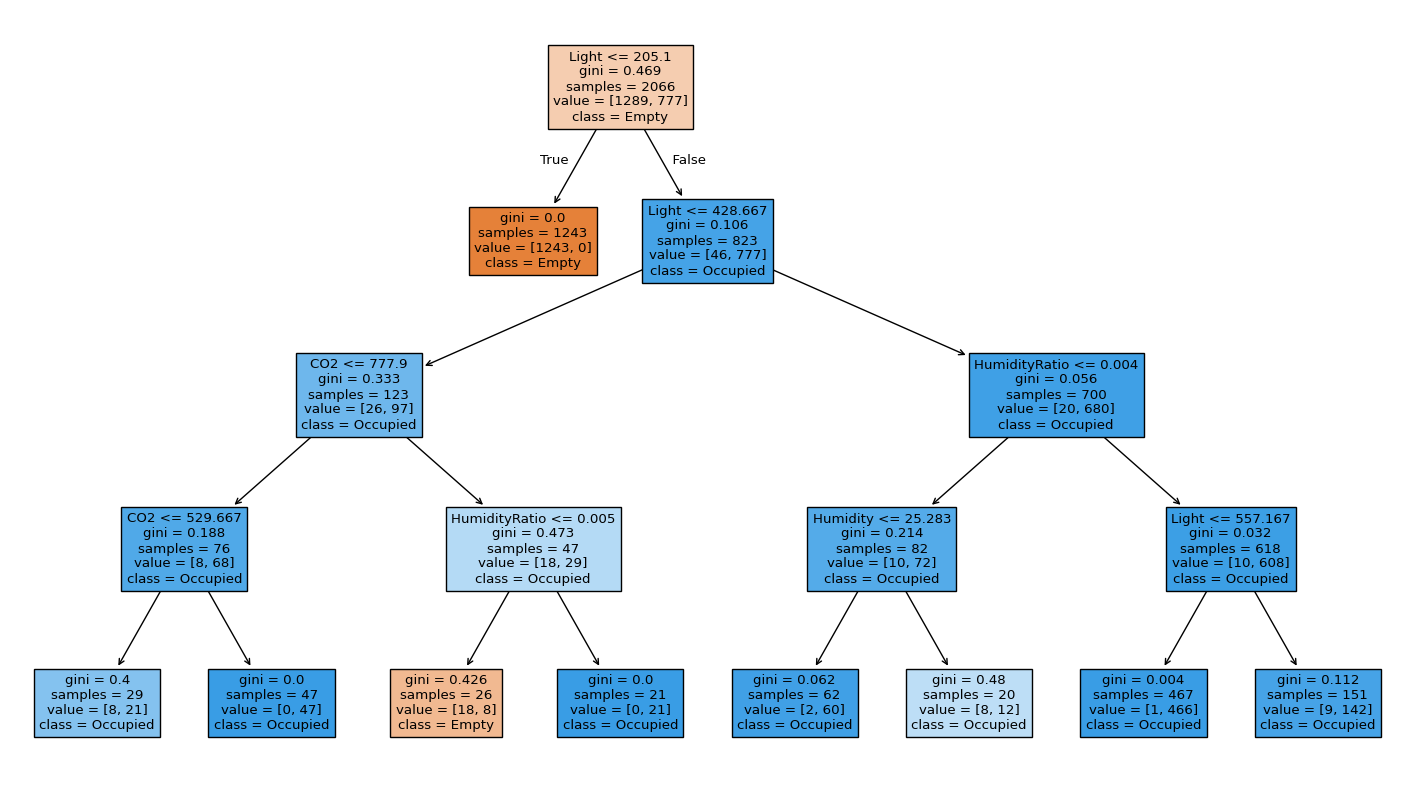

In [51]:
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Empty", "Occupied"],
    filled=True
)
plt.show()

In [52]:
feature_names = X.columns.tolist()
joblib.dump((model, feature_names), "occupancy_model.pkl")

['occupancy_model.pkl']